In [5]:
import sys
!python.exe -m pip install --upgrade pip

In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import warnings
warnings.filterwarnings("ignore")

In [7]:
df = pd.read_excel("C:/Users/hp/OneDrive/Desktop/Project github/finance_dataset_40000_rows.xlsx")

In [8]:
df.head()

,Transaction_ID,Date,Account_Type,Category,Description,Debit,Credit,Balance,Payment_Method,Bank_Name,City,Status
0,TXN000001,2025-02-23,Savings,Entertainment,Entertainment Transaction,3060,0,46940,Cash,HDFC,Delhi,Pending
1,TXN000002,2025-07-06,Savings,Grocery,Grocery Transaction,883,0,46057,Credit Card,SBI,Delhi,Pending
2,TXN000003,2025-07-01,Current,Grocery,Grocery Transaction,7833,0,38224,Cash,ICICI,Hyderabad,Pending
3,TXN000004,2025-08-27,Current,Food,Food Transaction,2459,0,35765,Cash,SBI,Jaipur,Failed
4,TXN000005,2025-10-13,Current,Entertainment,Entertainment Transaction,9797,0,25968,Debit Card,Punjab National Bank,Delhi,Failed


In [9]:
df.shape

(40000, 12)

In [10]:
df.isnull().sum()

Transaction_ID    0
Date              0
Account_Type      0
Category          0
Description       0
Debit             0
Credit            0
Balance           0
Payment_Method    0
Bank_Name         0
City              0
Status            0
dtype: int64

In [11]:
df.columns

Index(['Transaction_ID', 'Date', 'Account_Type', 'Category', 'Description',
       'Debit', 'Credit', 'Balance', 'Payment_Method', 'Bank_Name', 'City',
       'Status'],
      dtype='object')

In [12]:
df.isnull().mean()

Transaction_ID    0.0
Date              0.0
Account_Type      0.0
Category          0.0
Description       0.0
Debit             0.0
Credit            0.0
Balance           0.0
Payment_Method    0.0
Bank_Name         0.0
City              0.0
Status            0.0
dtype: float64

In [13]:
df.drop_duplicates(
    inplace=True)

In [14]:
df.columns.tolist()

['Transaction_ID',
 'Date',
 'Account_Type',
 'Category',
 'Description',
 'Debit',
 'Credit',
 'Balance',
 'Payment_Method',
 'Bank_Name',
 'City',
 'Status']

In [15]:
df.describe()

,Debit,Credit,Balance
count,40000.000000,40000.000000,4.000000e+04
mean,4531.525125,5583.151500,1.978674e+07
std,3110.543840,17218.378167,1.129750e+07
min,0.000000,0.000000,-1.428780e+05
25%,1727.000000,0.000000,1.089373e+07
50%,4478.000000,0.000000,1.992721e+07
75%,7248.000000,0.000000,2.896815e+07
max,10000.000000,79990.000000,4.229719e+07


In [17]:
#Loan amount by city and gender
pivot_loan = pd.pivot_table(
    df,
    values="Category",
    index="City",
    columns="Payment_Method",
    aggfunc="sum",
    fill_value=0
)

print(pivot_loan)

Payment_Method                                               Cash  \
City                                                                
Bangalore       TransportEMIFoodUtilitiesFoodShoppingSalaryHea...   
Chandigarh      EntertainmentShoppingUtilitiesGroceryTransport...   
Delhi           EntertainmentShoppingFoodSalaryHealthHealthSal...   
Hyderabad       GroceryHealthSalaryHealthUtilitiesSalaryInvest...   
Jaipur          FoodGroceryEMIHealthGroceryEMIShoppingGroceryG...   
Mumbai          GroceryUtilitiesTransportUtilitiesUtilitiesTra...   

Payment_Method                                        Credit Card  \
City                                                                
Bangalore       GroceryEMIFoodEntertainmentShoppingGroceryShop...   
Chandigarh      EntertainmentInvestmentFoodSalaryGroceryHealth...   
Delhi           GroceryEntertainmentShoppingSalaryEMIShoppingF...   
Hyderabad       InvestmentUtilitiesShoppingEntertainmentInvest...   
Jaipur          UtilitiesGroceryT

In [19]:
#Default count by purpose and employment
pivot_default = pd.pivot_table(
    df,
    values="Account_Type",
    index="Category",
    columns="Bank_Name",
    aggfunc="sum",
    fill_value=0
)

print(pivot_default)

Bank_Name                                                   Axis  \
Category                                                           
EMI            CurrentSavingsSavingsSavingsCurrentCurrentCurr...   
Entertainment  CurrentCurrentCurrentCurrentSavingsSavingsSavi...   
Food           CurrentCurrentSavingsCurrentSavingsSavingsCurr...   
Grocery        CurrentCurrentSavingsCurrentSavingsSavingsSavi...   
Health         CurrentSavingsSavingsSavingsCurrentSavingsCurr...   
Investment     CurrentCurrentSavingsCurrentSavingsCurrentCurr...   
Salary         SavingsCurrentSavingsCurrentCurrentCurrentCurr...   
Shopping       SavingsSavingsSavingsSavingsCurrentCurrentSavi...   
Transport      SavingsSavingsSavingsSavingsSavingsCurrentSavi...   
Utilities      SavingsSavingsSavingsSavingsSavingsCurrentSavi...   

Bank_Name                                                   HDFC  \
Category                                                           
EMI            CurrentCurrentCurrentCurrentSavi

In [22]:
import pandas as pd
import numpy as np
import panel as pn
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")


In [24]:
df = pd.read_excel("C:/Users/hp/OneDrive/Desktop/Project github/finance_dataset_40000_rows.xlsx")

In [27]:
# =========================
# KPI METRICS
# =========================
total_transactions = len(df)
total_debit = df['Debit'].sum()
total_credit = df['Credit'].sum()
current_balance = df['Balance'].iloc[-1]

In [29]:
# =========================
# KPI CARDS
# =========================
card_style = {
    'background': '#f5f5f5',
    'padding': '15px',
    'border-radius': '10px',
    'text-align': 'center',
    'box-shadow': '2px 2px 5px lightgray'
}

kpi1 = pn.pane.Markdown(
    f"## Total Transactions\n# {total_transactions:,}",
    styles=card_style
)

kpi2 = pn.pane.Markdown(
    f"## Total Debit\n# ₹ {total_debit:,.0f}",
    styles=card_style
)

kpi3 = pn.pane.Markdown(
    f"## Total Credit\n# ₹ {total_credit:,.0f}",
    styles=card_style
)

kpi4 = pn.pane.Markdown(
    f"## Current Balance\n# ₹ {current_balance:,.0f}",
    styles=card_style
)

kpi_row = pn.Row(kpi1, kpi2, kpi3, kpi4)

In [30]:

# =========================
# MONTHLY TREND
# =========================
df['Month'] = df['Date'].dt.strftime('%Y-%m')

monthly = df.groupby('Month')[['Debit', 'Credit']].sum().reset_index()

fig1, ax1 = plt.subplots(figsize=(10,5))

sns.lineplot(
    data=monthly,
    x='Month',
    y='Debit',
    marker='o',
    label='Debit',
    ax=ax1
)

sns.lineplot(
    data=monthly,
    x='Month',
    y='Credit',
    marker='o',
    label='Credit',
    ax=ax1
)

ax1.set_title("Monthly Debit vs Credit")
ax1.tick_params(axis='x', rotation=45)

trend_plot = pn.pane.Matplotlib(fig1, tight=True)

AttributeError: Can only use .dt accessor with datetimelike values

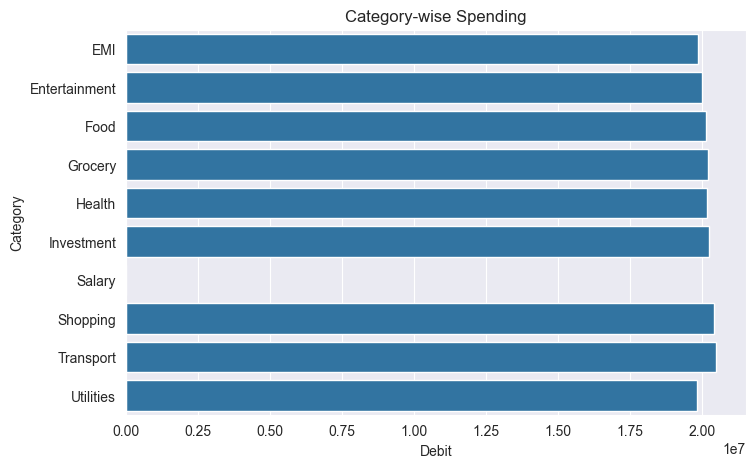

In [31]:
# =========================
# CATEGORY ANALYSIS
# =========================
category = df.groupby('Category')['Debit'].sum().reset_index()

fig2, ax2 = plt.subplots(figsize=(8,5))

sns.barplot(
    data=category,
    x='Debit',
    y='Category',
    ax=ax2
)

ax2.set_title("Category-wise Spending")

category_plot = pn.pane.Matplotlib(fig2, tight=True)


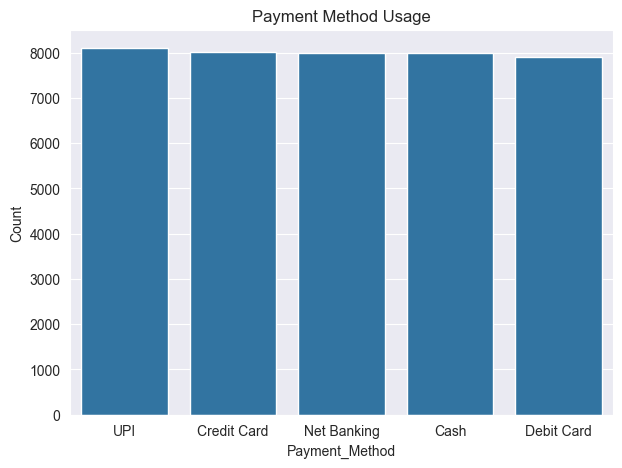

In [33]:
# =========================
# PAYMENT METHOD
# =========================
payment = df['Payment_Method'].value_counts().reset_index()
payment.columns = ['Payment_Method', 'Count']

fig3, ax3 = plt.subplots(figsize=(7,5))

sns.barplot(
    data=payment,
    x='Payment_Method',
    y='Count',
    ax=ax3
)

ax3.set_title("Payment Method Usage")

payment_plot = pn.pane.Matplotlib(fig3, tight=True)

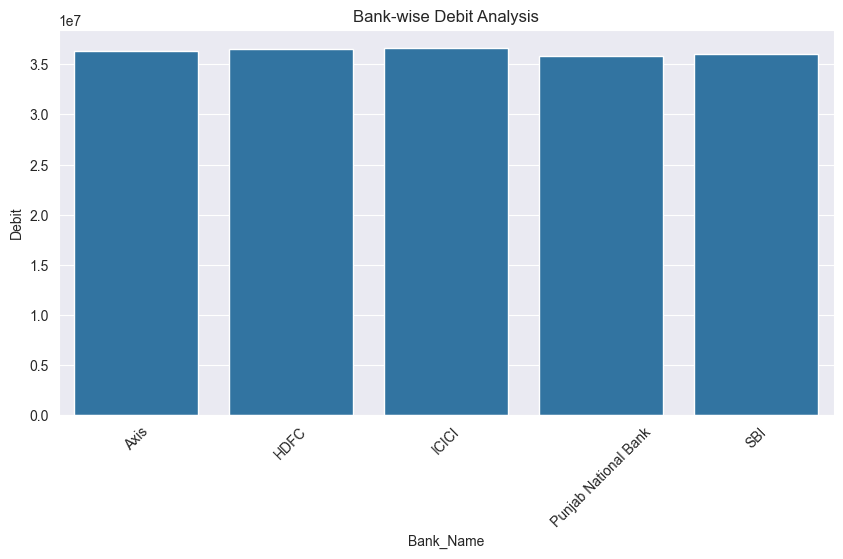

In [34]:
# =========================
# BANK ANALYSIS
# =========================
bank = df.groupby('Bank_Name')['Debit'].sum().reset_index()

fig4, ax4 = plt.subplots(figsize=(10,5))

sns.barplot(
    data=bank,
    x='Bank_Name',
    y='Debit',
    ax=ax4
)

ax4.set_title("Bank-wise Debit Analysis")
ax4.tick_params(axis='x', rotation=45)

bank_plot = pn.pane.Matplotlib(fig4, tight=True)


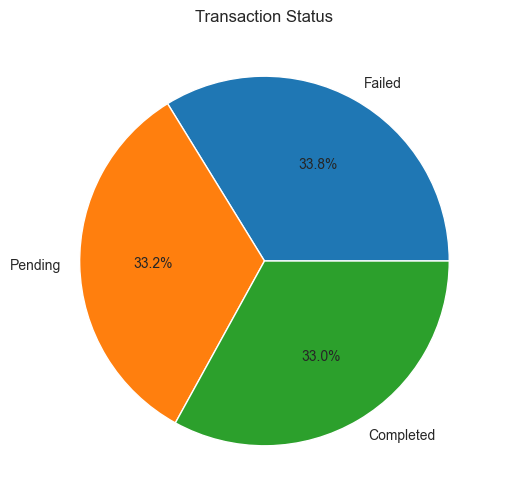

In [36]:
# =========================
# STATUS ANALYSIS
# =========================
status = df['Status'].value_counts()

fig5, ax5 = plt.subplots(figsize=(6,6))

ax5.pie(
    status.values,
    labels=status.index,
    autopct='%1.1f%%'
)

ax5.set_title("Transaction Status")

status_plot = pn.pane.Matplotlib(fig5, tight=True)

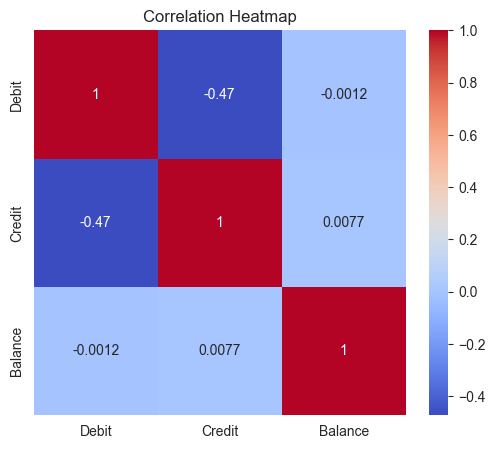

In [37]:

# =========================
# CORRELATION HEATMAP
# =========================
corr = df[['Debit', 'Credit', 'Balance']].corr()

fig6, ax6 = plt.subplots(figsize=(6,5))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    ax=ax6
)

ax6.set_title("Correlation Heatmap")

heatmap_plot = pn.pane.Matplotlib(fig6, tight=True)

In [40]:
# =========================
# DASHBOARD LAYOUT
# =========================
dashboard = pn.Column(
    pn.pane.Markdown(
        "# 🏦 Banking Transaction Dashboard",
        styles={'text-align': 'center'}
    ),

    kpi_row,



    pn.Row(category_plot, payment_plot),

    pn.Row(bank_plot, status_plot),

    pn.Row(heatmap_plot)
)

In [42]:

# =========================
# SERVE DASHBOARD
# =========================
dashboard.servable()

# RUN COMMAND:
# panel serve app.py --autoreload

Column
    [0] Markdown(str, styles={'text-align': 'center'})
    [1] Row
        [0] Markdown(str, styles={'background': '#f5f5f5', ...})
        [1] Markdown(str, styles={'background': '#f5f5f5', ...})
        [2] Markdown(str, styles={'background': '#f5f5f5', ...})
        [3] Markdown(str, styles={'background': '#f5f5f5', ...})
    [2] Row
        [0] Matplotlib(Figure, tight=True)
        [1] Matplotlib(Figure, tight=True)
    [3] Row
        [0] Matplotlib(Figure, tight=True)
        [1] Matplotlib(Figure, tight=True)
    [4] Row
        [0] Matplotlib(Figure, tight=True)